In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import numpy as np
import scipy.stats
from scipy.special import logit, expit
import matplotlib.pyplot as plt

import sys
sys.path.append('../../python/example/berry')
import util

sigma2_n = 90
n_arms = 2
mu_sig_sq = 100.0
mu_0 = -1.34
logit_p1 = logit(0.3)
n = np.full((1, 2), 35)
y = np.array([[0, 1]])
n.shape, y.shape

((1, 2), (1, 2))

In [4]:
sigma2_n = sigma2_n
sigma2_rule = util.log_gauss_rule(sigma2_n, 1e-6, 1e3)
arms = np.arange(n_arms)
cov = np.full((sigma2_n, n_arms, n_arms), mu_sig_sq)
cov[:, arms, arms] += sigma2_rule.pts[:, None]
neg_precQ = -np.linalg.inv(cov)
logprecQdet = 0.5 * np.log(np.linalg.det(-neg_precQ))
log_prior = scipy.stats.invgamma.logpdf(
    sigma2_rule.pts, 0.0005, scale=0.000005
)

In [5]:
def calc_log_joint(theta, sig_idx):
    theta_m0 = theta - mu_0
    theta_adj = theta + logit_p1
    exp_theta_adj = np.exp(theta_adj)
    out = (
        0.5 * np.einsum("...i,...ij,...j", theta_m0, neg_precQ[sig_idx], theta_m0)
        + np.sum(
            theta_adj * y - n * np.log(exp_theta_adj + 1),
            axis=-1,
        )
    )
    out -= np.max(out)
    return out

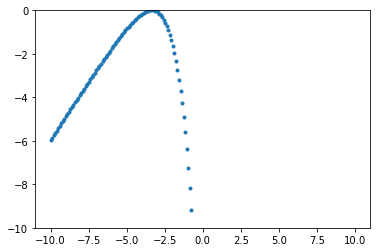

In [6]:
ts = np.linspace(-10, 10, 200)
theta2d = np.meshgrid(ts, ts, indexing = 'ij')
theta = np.stack([ti.ravel() for ti in theta2d], axis=-1)
theta1d = np.stack((theta2d[0][:,0], theta2d[0][:,0]),axis=-1)
theta1d[:,1] = theta1d[:,0]
theta = theta1d
sig_idx = 0
logjoint = calc_log_joint(theta, sig_idx)
logjoint -= logjoint.max()
levels = np.linspace(-10, 0, 21)
plt.plot(theta1d[:,0], logjoint, '.')
plt.ylim([-10, 0])
plt.show()

In [7]:
import berry
import inla
import quadrature
import fast_inla

fi = fast_inla.FastINLA(n_arms, sigma2_n=sigma2_n)

/Users/tbent/.mambaforge/envs/kevlar/lib/python3.10/site-packages/jax/_src/lib/__init__.py:33: UserWarning: JAX on Mac ARM machines is experimental and minimally tested. Please see https://github.com/google/jax/issues/5501 in the event of problems.
  warnings.warn("JAX on Mac ARM machines is experimental and minimally tested. "


/Users/tbent/.mambaforge/envs/kevlar/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


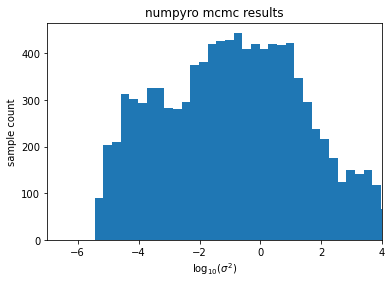

In [8]:
import mcmc

results_mcmc = mcmc.mcmc_berry(
    np.stack((y,n), axis=-1),
    fi.logit_p1,
    np.full(y.shape[0], fi.thresh_theta),
    n_arms=n_arms,
    dtype=np.float64,
    n_samples=10000
)

sigma2_mcmc = results_mcmc["x"][0]["sigma2"][0]
plt.title("numpyro mcmc results")
plt.hist(np.log10(sigma2_mcmc.to_py()), bins=40)
plt.xlabel("$\log_{10} (\sigma^2)$")
plt.ylabel("sample count")
plt.xlim([-7, 4])
plt.show()

mcmc_cdf = (sigma2_mcmc[None, :] < fi.sigma2_rule.pts[:, None]).sum(axis=1)
mcmc_pdf = np.zeros(fi.sigma2_rule.pts.shape[0])
mcmc_pdf[1:] = (mcmc_cdf[1:] - mcmc_cdf[:-1]) / sigma2_mcmc.shape[0]

In [9]:
n_theta = 11
w_theta = 10
integrate_sigma2 = False
fixed_arm_dim = None
fixed_arm_values = None

In [10]:
N, R = y.shape
S = fi.sigma2_n
integrate_thetas = list(range(fi.n_arms))
if fixed_arm_dim is not None:
    integrate_thetas.remove(fixed_arm_dim)

etapts, etawts = np.polynomial.legendre.leggauss(n_theta)
grid_eta = np.stack(
    np.meshgrid(*[etapts for k in integrate_thetas], indexing="ij"), axis=-1
)
grid_eta_wts = np.prod(
    np.stack(
        np.meshgrid(*[etawts for k in integrate_thetas], indexing="ij"), axis=-1
    ),
    axis=-1,
)

# Compute mode and the inverse hessian at the mode via INLA!
if fixed_arm_dim is None:
    mode, hess_inv = fi.optimize_mode(y, n)
else:
    M = fixed_arm_values.shape[0]
    y_tiled = np.tile(y[:, None, :], (1, M, 1)).reshape((-1, R))
    n_tiled = np.tile(n[:, None, :], (1, M, 1)).reshape((-1, R))
    arm_values_tiled = np.tile(fixed_arm_values[None, :, None], (N, 1, S)).reshape(
        (-1, S)
    )
    mode, hess_inv = fi.optimize_mode(
        y_tiled,
        n_tiled,
        fixed_arm_dim=fixed_arm_dim,
        fixed_arm_values=arm_values_tiled,
    )

# Step 2: decorrelate our coordinate system.
# the negative of hess_inv is the covariance matrix. We take the subset
# corresponding to the dimensions we will be integrating over.
w, v = np.linalg.eigh(-hess_inv)
axis_half_len = np.sqrt(np.abs(w))

# Step 3: explore the coordinate system axis to determine the necessary domain scale.
mode_logjoint = fi.log_joint(y, n, mode)
log_tol = np.log(1e-10)
lr = 0.25
for eigen_idx in range(len(integrate_thetas)):
    dir_steps = np.empty((2, *mode.shape[:2]))
    for i, direction in enumerate([-1, 1]):
        step = np.full(mode.shape[:2], direction)
        for j in range(10):
            probe = (
                mode
                + axis_half_len[..., eigen_idx, None]
                * v[..., :, eigen_idx]
                * step[..., None]
            )
            logjoint = fi.log_joint(y, n, probe)
            delta = logjoint - mode_logjoint
            step = (1 - lr) * step + lr * step * (log_tol / delta)
            step[step * direction < 0] = direction
        dir_steps[i] = step
    # TODO: convergence test
    axis_half_len[..., eigen_idx] *= np.max(np.abs(dir_steps), axis=0)

# Map the coordinates from eta to theta space.
mode_subset = mode[..., integrate_thetas]
broadcast_shape = list(mode_subset.shape)
for i in range(len(integrate_thetas)):
    broadcast_shape.insert(1, 1)
grid_theta = np.einsum(
    "klij,...i,kli->k...lj", v, grid_eta, axis_half_len
) + mode_subset.reshape(broadcast_shape)

# Map the quadrature weights from eta to theta space.
# We need to multiply by the absolute value of the determinant of the
# transformation. Because we have already computed a eigendecomposition, the
# determinant of matrix is just product of eigenvalues.
det_jacobian = axis_half_len.prod(axis=-1)
grid_theta_wts = np.einsum("kl,...->k...l", det_jacobian, grid_eta_wts)

# Reshape the final results to:
# (N, n_theta1, ..., n_thetaM, n_sigma2, n_arms + 1)
# The entries corresponding to theta_i will be full_grid[..., i]
# while the entries corresponding to sigma2 will be full_grid[..., -1]
full_grid = np.empty((*grid_theta.shape[:-1], R + 1))
full_grid[..., integrate_thetas] = grid_theta
full_grid[..., fi.n_arms] = util.broadcast(
    fi.sigma2_rule.pts, full_grid.shape[:-1], [-1]
)
full_wts = grid_theta_wts
if fixed_arm_dim is not None:
    final_shape = [N, M] + list(full_grid.shape[1:])
    full_grid = full_grid.reshape(final_shape)
    full_grid[..., fixed_arm_dim] = util.broadcast(
        fixed_arm_values, full_grid.shape[:-1], [1]
    )
    full_wts = grid_theta_wts.reshape(final_shape[:-1])

if integrate_sigma2:
    full_wts *= util.broadcast(fi.sigma2_rule.wts, full_wts.shape, [-1])

10


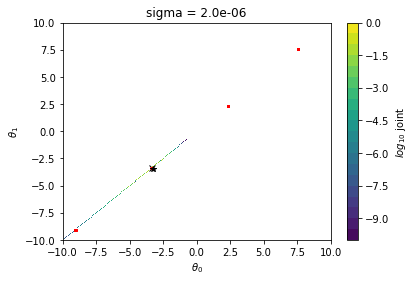

In [11]:
ts = np.linspace(-10, 10, 200)
theta2d = np.meshgrid(ts, ts, indexing = 'ij')
theta = np.stack([ti.ravel() for ti in theta2d], axis=-1)
for sig_idx in [10]:#range(0, sigma2_n, 1):
    print(sig_idx)
    logjoint = calc_log_joint(theta, sig_idx)

    levels = np.linspace(-10, 0, 21)
    plt.contourf(theta2d[0], theta2d[1], logjoint.reshape(theta2d[0].shape), levels=levels)
    plt.plot(*mode[0,sig_idx], 'kx')

    # plt.plot(new_pts[0, :, :, sig_idx,0].ravel(), new_pts[0, :,:,sig_idx,1].ravel(), 'ko', markersize=8)
    plt.plot(grid_theta[0, :,:, sig_idx, 0].ravel(), grid_theta[0, :,:, sig_idx, 1].ravel(), 'ro', markersize=2)

    plt.plot(*(mode[0,sig_idx] + axis_half_len[0,sig_idx,0] * w_theta * v[0,sig_idx,0]), 'k*')
    plt.plot(*(mode[0,sig_idx] + axis_half_len[0,sig_idx,1] * w_theta * v[0,sig_idx,1]), 'k*')
    plt.xlabel(r'$\theta_0$')
    plt.ylabel(r'$\theta_1$')

    plt.title(f'sigma = {sigma2_rule.pts[sig_idx]:.1e}')
    cbar = plt.colorbar()
    cbar.set_label('$log_{10}$ joint')
    plt.xlim([ts.min(), ts.max()])
    plt.ylim([ts.min(), ts.max()])
    plt.show()

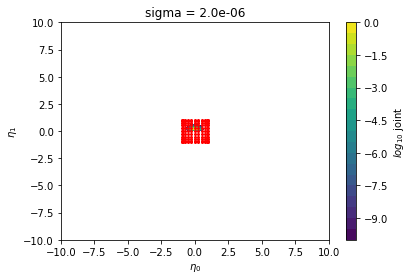

In [12]:
sig_idx = 10
eta = np.stack([ti.ravel() for ti in theta2d], axis=-1)
theta = (eta * axis_half_len[0,sig_idx]).dot(v[0,sig_idx])
logjoint = calc_log_joint(theta, sig_idx)

levels = np.linspace(-10, 0, 21)
plt.contourf(theta2d[0], theta2d[1], logjoint.reshape(theta2d[0].shape), levels=levels)

plt.plot(grid_eta[:,:,0].ravel(), grid_eta[:,:,1].ravel(), 'ro', markersize=2)
plt.xlabel(r'$\eta_0$')
plt.ylabel(r'$\eta_1$')

plt.title(f'sigma = {sigma2_rule.pts[sig_idx]:.1e}')
cbar = plt.colorbar()
cbar.set_label('$log_{10}$ joint')
plt.xlim([ts.min(), ts.max()])
plt.ylim([ts.min(), ts.max()])
plt.show()

In [13]:
sigma2_post_fi, _, _, _ = fi.inference(y, n)

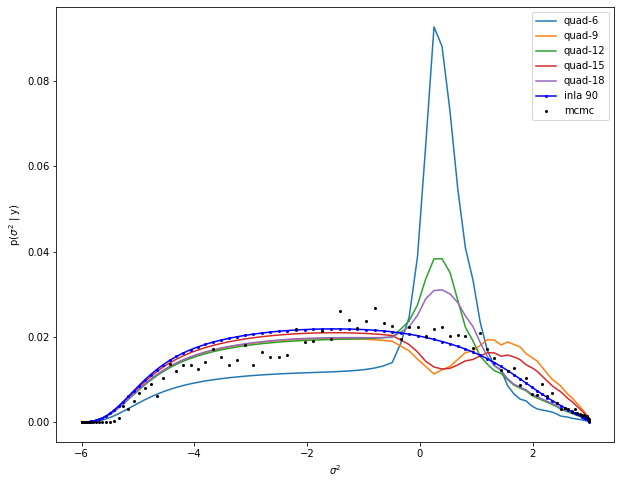

In [14]:
plt.figure(figsize=(10,8))
for nq in [6, 9, 12, 15, 18]:
    full_grid, full_wts = quadrature.build_grid(
        fi, y, n, integrate_sigma2=False, n_theta=nq, w_theta=w_theta
    )
    pr = full_grid[...,:2].reshape((-1, fi.sigma2_n, fi.n_arms))
    log_joint = fi.log_joint(y, n, pr).reshape(full_grid.shape[:-1])
    integral = (np.exp(log_joint) * full_wts).sum(axis=(1,2))
    denom = (integral * fi.sigma2_rule.wts).sum()
    integral[0] /= denom
    plt.plot(np.log10(fi.sigma2_rule.pts), integral[0] * fi.sigma2_rule.wts, label = f'quad-{nq}')
plt.plot(np.log10(fi.sigma2_rule.pts), sigma2_post_fi[0] * fi.sigma2_rule.wts, 'b-o', markersize=2, label='inla 90')
plt.plot(np.log10(fi.sigma2_rule.pts), mcmc_pdf, 'ko', markersize=2, label='mcmc')
plt.legend()
plt.xlabel('$\sigma^2$')
plt.ylabel('p($\sigma^2$ | y)')
plt.show()

/var/folders/mt/cmys2v_143q1kpcrdt5wcdyr0000gn/T/ipykernel_89163/335717603.py:13: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(fi.sigma2_rule.pts), np.log10(mcmc_pdf / fi.sigma2_rule.wts), 'mo', markersize=2, label='mcmc')


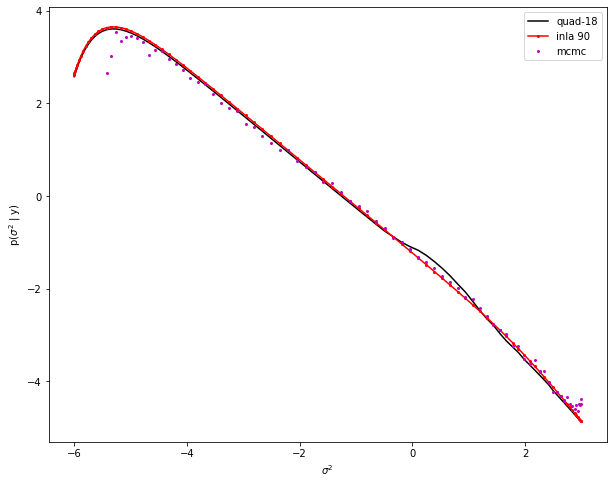

In [15]:
plt.figure(figsize=(10,8))
for nq in [18]:
    full_grid, full_wts = quadrature.build_grid(
        fi, y, n, integrate_sigma2=False, n_theta=nq, w_theta=w_theta
    )
    pr = full_grid[...,:2].reshape((-1, fi.sigma2_n, fi.n_arms))
    log_joint = fi.log_joint(y, n, pr).reshape(full_grid.shape[:-1])
    integral = (np.exp(log_joint) * full_wts).sum(axis=(1,2))
    denom = (integral * fi.sigma2_rule.wts).sum()
    integral[0] /= denom
    plt.plot(np.log10(fi.sigma2_rule.pts), np.log10(integral[0]), 'k-', label = f'quad-{nq}')
plt.plot(np.log10(fi.sigma2_rule.pts), np.log10(sigma2_post_fi[0]), 'r-o', markersize=2, label='inla 90')
plt.plot(np.log10(fi.sigma2_rule.pts), np.log10(mcmc_pdf / fi.sigma2_rule.wts), 'mo', markersize=2, label='mcmc')
plt.legend()
plt.xlabel('$\sigma^2$')
plt.ylabel('p($\sigma^2$ | y)')
plt.show()

In [16]:
ti_N = 101
ti_rule = util.simpson_rule(ti_N, -6.0, 2.0)

In [28]:
grids, wts = quadrature.build_grid(
    fi, y, n, fixed_arm_dim=0, fixed_arm_values=ti_rule.pts, n_theta=21
)
grids_ravel = grids[..., : fi.n_arms].reshape((-1, fi.sigma2_n, fi.n_arms))
logjoint = fi.log_joint(y[None, :], n[None, :], grids_ravel).reshape(
    grids.shape[:-1]
)

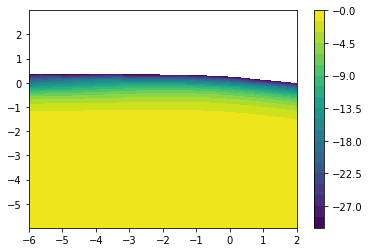

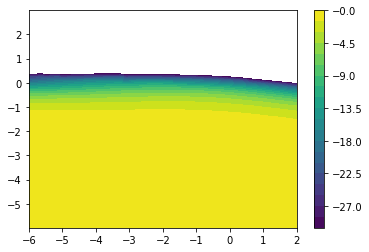

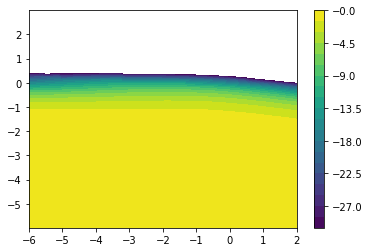

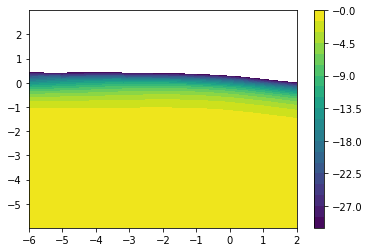

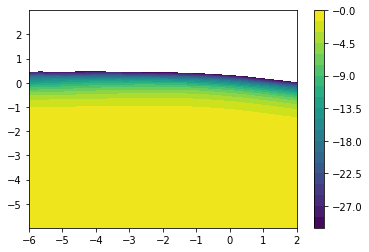

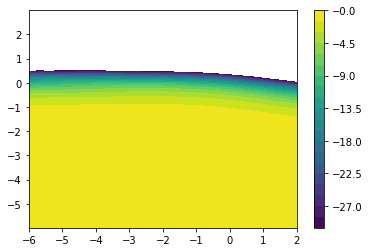

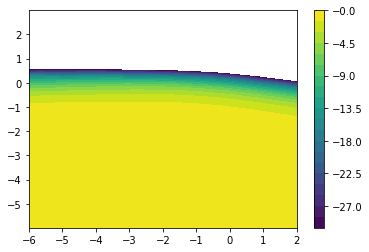

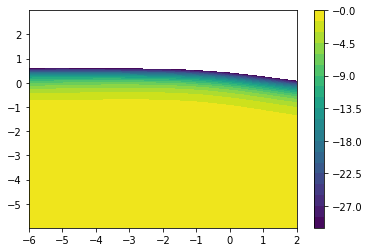

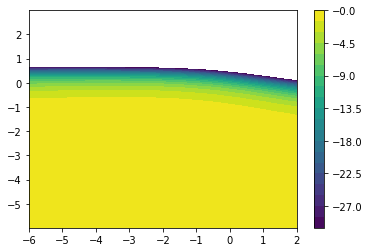

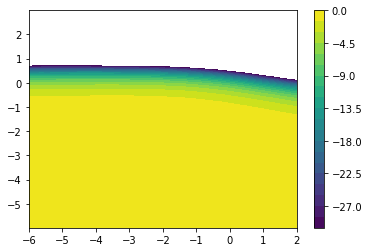

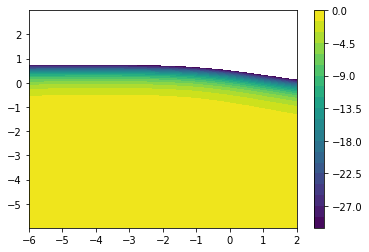

In [29]:
for i in range(0, 11, 1):
    field = logjoint[0, :, i, :] * fi.sigma2_rule.wts
    levels = np.linspace(np.max(field) - 30, np.max(field), 21)
    plt.contourf(grids[0, :, i, :, 0], np.log10(grids[0, :, i, :, 2]), field, levels=levels)
    plt.colorbar()
    plt.show()

In [30]:
grids[0, :, :, i, 1]

array([[-6.02007212, -6.01953625, -6.01858416, ..., -5.98140779,
        -5.9804557 , -5.97991983],
       [-5.94007214, -5.93953626, -5.93858418, ..., -5.9014078 ,
        -5.90045572, -5.89991984],
       [-5.86007215, -5.85953628, -5.85858419, ..., -5.82140782,
        -5.82045573, -5.81991986],
       ...,
       [ 1.81982393,  1.8203598 ,  1.82131187, ...,  1.85848772,
         1.85943979,  1.85997566],
       [ 1.8998217 ,  1.90035757,  1.90130965, ...,  1.93848552,
         1.93943759,  1.93997346],
       [ 1.97981956,  1.98035543,  1.98130751, ...,  2.0184834 ,
         2.01943547,  2.01997134]])

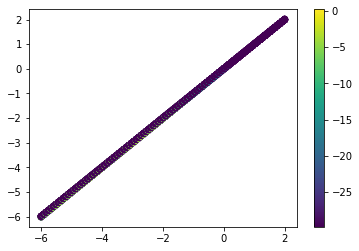

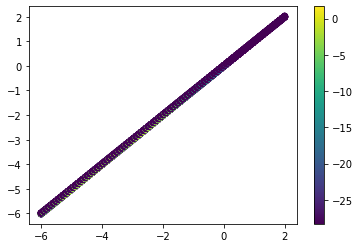

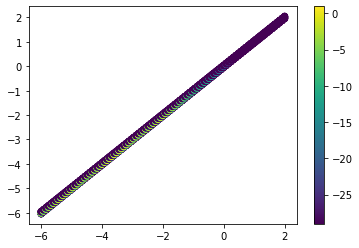

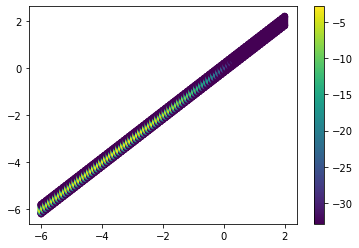

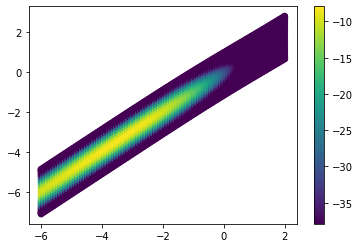

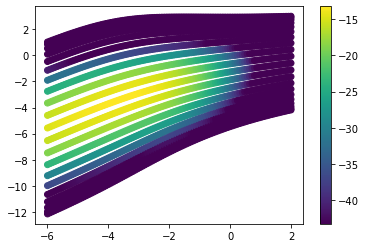

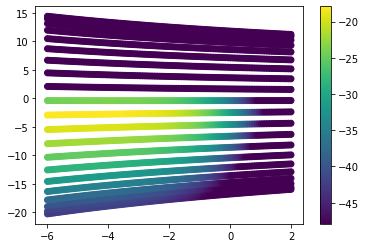

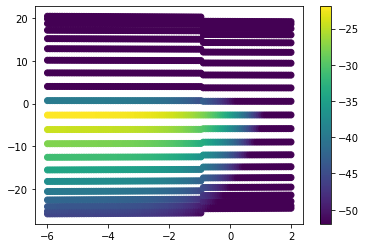

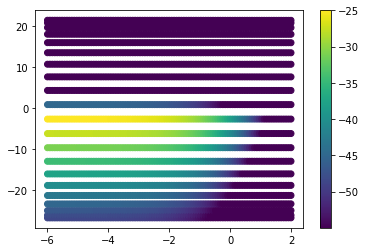

In [31]:
for i in range(0, 90, 10):
    field = logjoint[0, :, :, i]
    vmax = np.max(field)
    vmin = vmax - 30
    levels = np.linspace(vmin, vmax, 21)
    plt.scatter(grids[0, :, :, i, 0], grids[0, :, :, i, 1], c=field, vmin=vmin, vmax=vmax)
    # plt.contourf(grids[0, :, :, i, 0], grids[0, :, :, i, 1], field, levels=levels)
    plt.colorbar()
    plt.show()

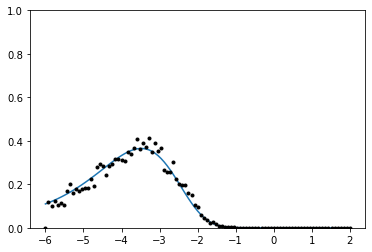

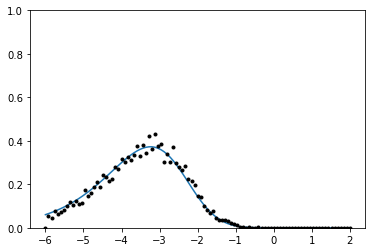

In [32]:
for arm_idx in range(2):
    mcmc_arm = results_mcmc["x"][0]['theta'][0,:,arm_idx].to_py() 
    mcmc_arm_cdf = (mcmc_arm[None, :] < ti_rule.pts[:, None]).sum(axis=1)
    mcmc_arm_pdf = np.zeros(ti_rule.pts.shape[0])
    mcmc_arm_pdf[1:] = (mcmc_arm_cdf[1:] - mcmc_arm_cdf[:-1]) / mcmc_arm.shape[0]
    mcmc_arm_pdf /= np.sum(mcmc_arm_pdf * ti_rule.wts)

    quad_p_ti_g_y = quadrature.integrate(
        fi, y, n, fixed_arm_dim=arm_idx, fixed_arm_values=ti_rule.pts,
        n_theta=21
    )
    quad_p_ti_g_y /= np.sum(quad_p_ti_g_y * ti_rule.wts, axis=1)[:, None]
    plt.plot(ti_rule.pts, quad_p_ti_g_y[0])
    plt.plot(ti_rule.pts, mcmc_arm_pdf, 'k.')
    plt.ylim([0, 1.0])
    plt.show()